**STOCK MARKET PREDICTION PROJECT**

**Import Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [4]:
df=pd.read_csv('applestock.csv')

In [5]:
df.head()

,datetime,open,high,low,close,volume
0,2018-12-10 18:15:00,41.33,41.34,41.16,41.23,542515
1,2018-12-10 18:20:00,41.23,41.28,41.13,41.16,483127
2,2018-12-10 18:25:00,41.16,41.30,41.15,41.30,535501
3,2018-12-10 18:30:00,41.30,41.33,41.19,41.19,508917
4,2018-12-10 18:35:00,41.20,41.36,41.18,41.34,500652


In [6]:
df.isnull().sum()

,0
datetime,0
open,0
high,0
low,0
close,0
volume,0


In [7]:
df.isnull().any()

,0
datetime,False
open,False
high,False
low,False
close,False
volume,False


In [8]:
df.describe

<bound method NDFrame.describe of                    datetime    open    high     low   close   volume
0       2018-12-10 18:15:00   41.33   41.34   41.16   41.23   542515
1       2018-12-10 18:20:00   41.23   41.28   41.13   41.16   483127
2       2018-12-10 18:25:00   41.16   41.30   41.15   41.30   535501
3       2018-12-10 18:30:00   41.30   41.33   41.19   41.19   508917
4       2018-12-10 18:35:00   41.20   41.36   41.18   41.34   500652
...                     ...     ...     ...     ...     ...      ...
103628  2024-03-13 22:40:00  171.47  171.65  171.47  171.60   515713
103629  2024-03-13 22:45:00  171.59  171.71  171.50  171.66   566382
103630  2024-03-13 22:50:00  171.65  171.65  171.19  171.29   869695
103631  2024-03-13 22:55:00  171.30  171.30  171.04  171.15  1413942
103632  2024-03-13 23:00:00  171.14  171.16  171.11  171.12    21317

[103633 rows x 6 columns]>

In [9]:
df.dtypes

,0
datetime,object
open,float64
high,float64
low,float64
close,float64
volume,int64


**Feature Engineering**

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute

df.drop("datetime", axis=1, inplace=True)

**Exploratory Data Analysis**

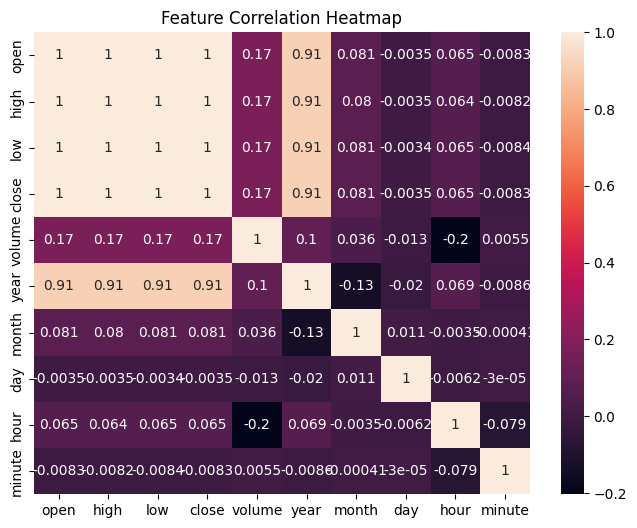

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'year', 'month', 'day',
       'hour', 'minute'],
      dtype='object')

**Features and Target**

In [13]:
x=df.drop(['close'],axis=1)
y=df['close']

**Train Test Split**

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**ML Models**

In [15]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [16]:
lr.fit(x_train,y_train)

LinearRegression()

In [17]:
y_pred=lr.predict(x_test)

**evalution of models**

In [18]:
from sklearn.metrics import mean_squared_error as mse,r2_score as r2

In [19]:
MSE=mse(y_test,y_pred)
R2=r2(y_test,y_pred)

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR

models={
    'LinearRegression':LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    'RandomForestRegressor':RandomForestRegressor(),
    'XGBRegressor':XGBRegressor(),
    'AdaBoostRegressor':AdaBoostRegressor(),
    'GradientBoostingRegressor':GradientBoostingRegressor(),
    'kNeighborsRegressor':KNeighborsRegressor(),
    'LinearSVR':LinearSVR()
}

**Train and Evaluate Models**

In [21]:
result={}
for name,model in models.items():
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  MSE=mse(y_test,y_pred)
  R2=r2(y_test,y_pred)
  print(f"{name} R2:{R2}")
  print(f"{name} MSE:{MSE}")
  result[name]=R2
best_model = max(result, key=result.get)
print(f"BEST MODEL:{best_model}")





LinearRegression R2:0.9999959584796985
LinearRegression MSE:0.009064436558146347
Decision Tree R2:0.9999898079864247
Decision Tree MSE:0.022858937617600186
RandomForestRegressor R2:0.9999942306352821
RandomForestRegressor MSE:0.012939695105900663
XGBRegressor R2:0.9999819064029014
XGBRegressor MSE:0.04058083363988445
AdaBoostRegressor R2:0.997027125608609
AdaBoostRegressor MSE:6.667647148989577
GradientBoostingRegressor R2:0.9999506114811885
GradientBoostingRegressor MSE:0.1107699731949114
kNeighborsRegressor R2:0.8272800492645442
kNeighborsRegressor MSE:387.3812127514836
LinearSVR R2:0.9999796443992653
LinearSVR MSE:0.04565411966192234
BEST MODEL:LinearRegression


In [28]:
best_model = max(result, key=result.get)
print(f"BEST MODEL:{best_model}")

BEST MODEL:LinearRegression


REMINDER: After checking the metrics values of some best regressive algorithms the LinearRegression model has best performance among them so, we ar egoing to use Linearg=regression model for our stock prediction.

**Feature Scaling by using Standardization**

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scale_train=sc.fit_transform(x_train)
x_scale_test=sc.transform(x_test)


In [30]:
lr=LinearRegression()
lr.fit(x_scale_train,y_train)
y_pred=lr.predict(x_scale_test)

In [31]:
print(f"R2 SCORE:{r2(y_test,y_pred)}")

R2 SCORE:0.9999959584796985


NOTE: Even after the Standardization of the datapoints the perormance is similar.

**Model Comparison Visualization**

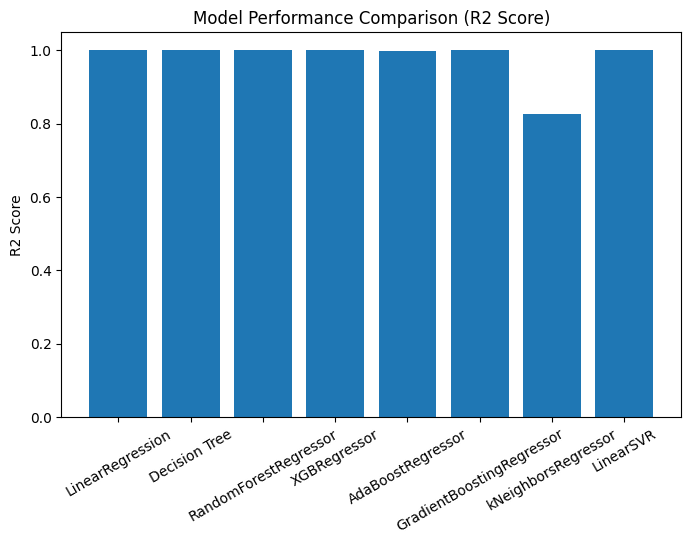

In [32]:
plt.figure(figsize=(8,5))
plt.bar(result.keys(), result.values())

plt.title("Model Performance Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)

plt.show()

**Actual vs Predicted Visualization**

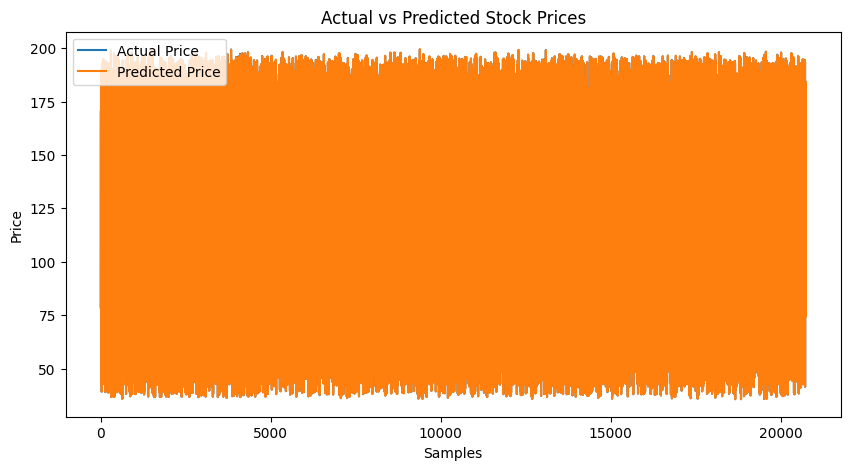

In [34]:
predictions = models[best_model].predict(x_test)

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Samples")
plt.ylabel("Price")

plt.legend()

plt.show()

ENTER THE ATTRIBUTES/INPUTS FOR STOCKS TO PREDICT THE CLOSING


INPUTS:open,high,low,volume

**User Input Function**

In [35]:
def predict_stock(model):

    open_price = float(input("Enter Open Price: "))
    high = float(input("Enter High Price: "))
    low = float(input("Enter Low Price: "))
    volume = float(input("Enter Volume: "))
    year = int(input("Enter Year: "))
    month = int(input("Enter Month: "))
    day = int(input("Enter Day: "))
    hour = int(input("Enter Hour: "))
    minute = int(input("Enter Minute: "))

    features = [[open_price, high, low, volume, year, month, day, hour, minute]]

    prediction = model.predict(features)

    print("Predicted Closing Price:", prediction[0])

In [40]:
predict_stock(models[best_model])

Enter Open Price: 23554
Enter High Price: 234566
Enter Low Price: 211
Enter Volume: 120000
Enter Year: 2020
Enter Month: 12
Enter Day: 12
Enter Hour: 12
Enter Minute: 12
Predicted Closing Price: 173160.0530335882
